In [1]:
import os
import cv2
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

import nengo 
import nengo_spa as spa
import sspspace

DATA_PATH = '/scratch/users/penzkofer/AV-Learning/android/'

```python 
DATA_PATH = '/scratch/users/penzkofer/AV-Learning/android/'
file_lst = os.listdir(DATA_PATH)

for i in range(len(file_lst)):
    path = os.path.join(DATA_PATH, file_lst[i])
    
    z = int(file_lst[i].split('_')[0]) // 3
    img = cv2.imread(path)
    binary_img = np.max(img, axis=2) // 255
    
    cv2.imwrite(f'data/android_{z:03d}_roi.png', binary_img)

plt.imshow(binary_img, cmap='gray')
```

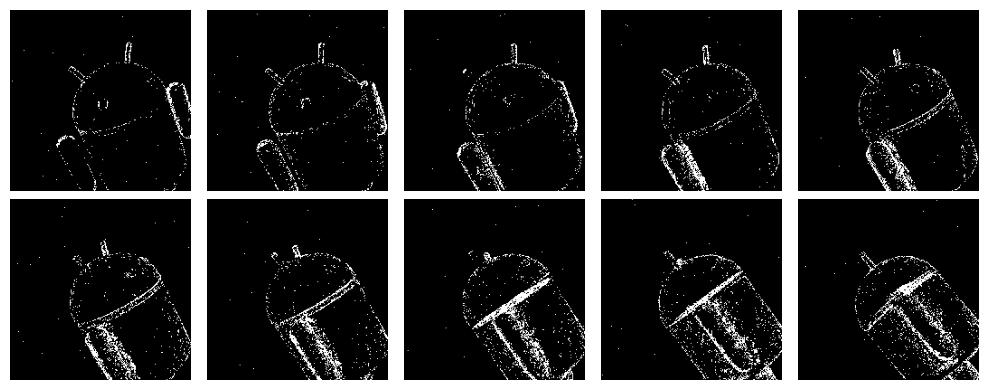

In [14]:
DATA_PATH = '/scratch/users/penzkofer/AV-Learning/data/'
file_lst = sorted([f for f in os.listdir(DATA_PATH) if 'android' in f])

fig, axs = plt.subplots(figsize=(10, 4), ncols=5, nrows=2)
skip = 5
all_imgs = {}
for i in range(0, len(file_lst), skip)[:10]:
    
    path = os.path.join(DATA_PATH, file_lst[i])
    z = int(file_lst[i].split('_')[1])
    img = cv2.imread(path)
    
    img = cv2.resize(img, (200, 200), interpolation=cv2.INTER_CUBIC)
    img = np.max(img, axis=2)
    i = i // skip
    axs[i // 5, i % 5].imshow(img.astype(float), cmap='gray')
    axs[i // 5, i % 5].set_axis_off() 
    all_imgs[z] = img

plt.tight_layout()
plt.show()

In [3]:
def plot_sample(image, simsmap, threshold=0.7, save=None):
    
    f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 3))

    ax1.imshow(image, cmap='gray')
    ax1.set_title('mask')
    ax1.axis('off')

    ax2.imshow(simsmap)
    ax2.set_title('similarity map')
    ax2.axis('off')

    ax3.imshow(simsmap > threshold, cmap='gray')
    ax3.set_title(f'predicted map - threshold {threshold}')
    ax3.axis('off')
    
    plt.tight_layout()
    
    if save is not None: 
        plt.savefig(save, dpi=100)
        
    plt.show()
    
def calc_iou(pred, gt): 
    """ calculates intersection-over-union (IoU) for pixel-based segmentation maps 
    iou = tp / (tp + fp + fn)
    see https://learnopencv.com/intersection-over-union-iou-in-object-detection-and-segmentation/#IoU-in-Image-Segmentattion
    """
    intersect = pred[pred == gt]
    opposite = pred[pred != gt]

    tn, tp = np.bincount(intersect.flatten(), minlength=2)
    fn, fp = np.bincount(opposite.flatten(), minlength=2)
    iou = tp / (tp + fp + fn)
    
    return iou, (tp, tn, fp, fn)

## Encode single image

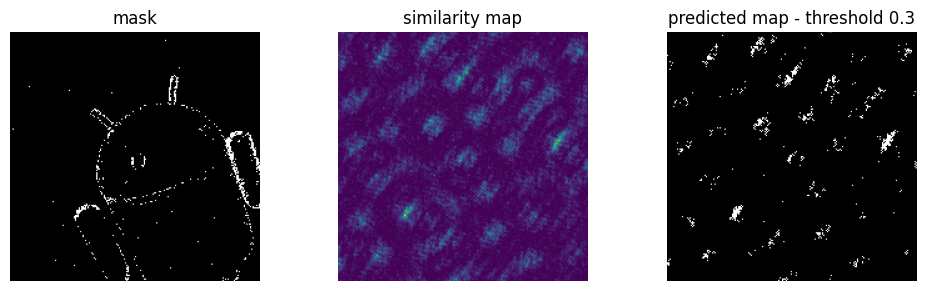

lengthscale   0.5 -- reconstruction IoU 10.86%


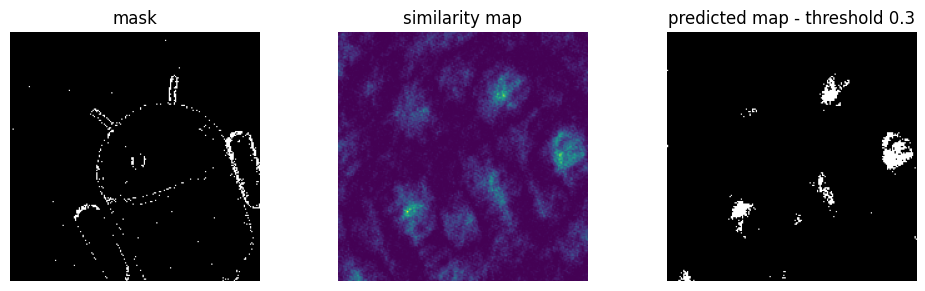

lengthscale   1.0 -- reconstruction IoU 16.58%


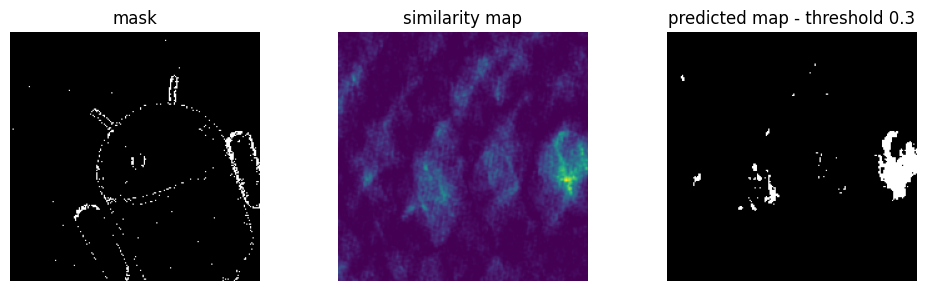

lengthscale   1.5 -- reconstruction IoU 16.82%


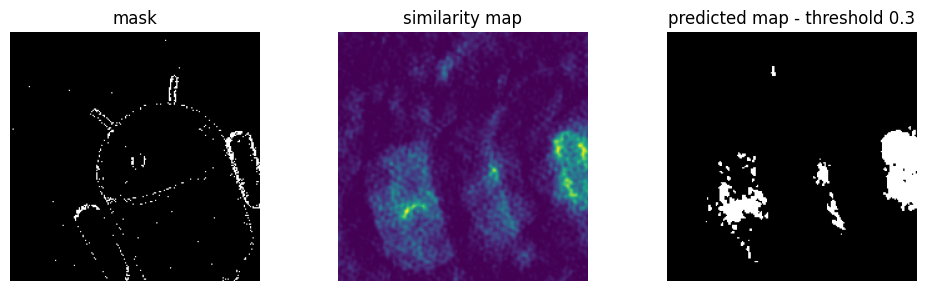

lengthscale   2.0 -- reconstruction IoU 12.37%


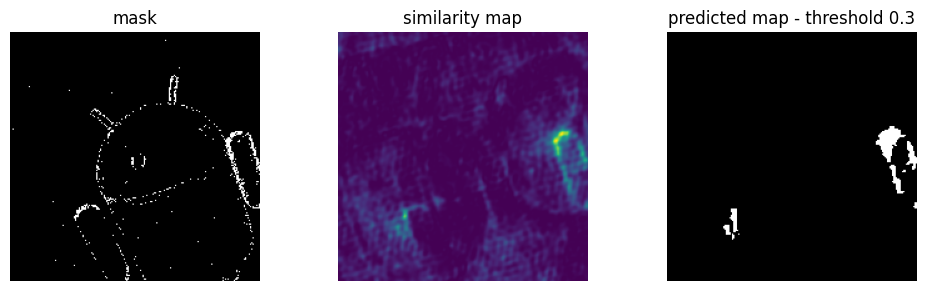

lengthscale   2.5 -- reconstruction IoU 20.52%


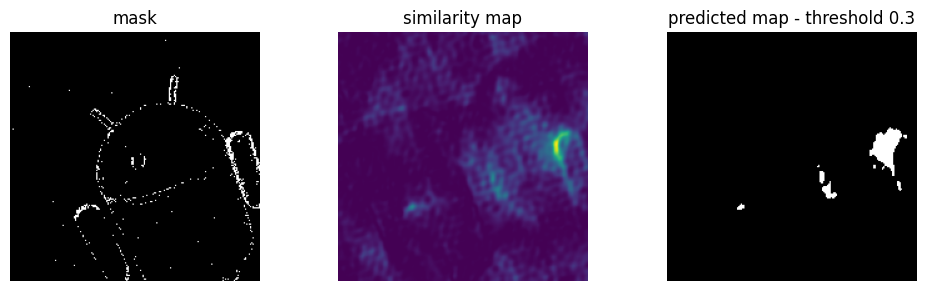

lengthscale   3.0 -- reconstruction IoU 12.85%


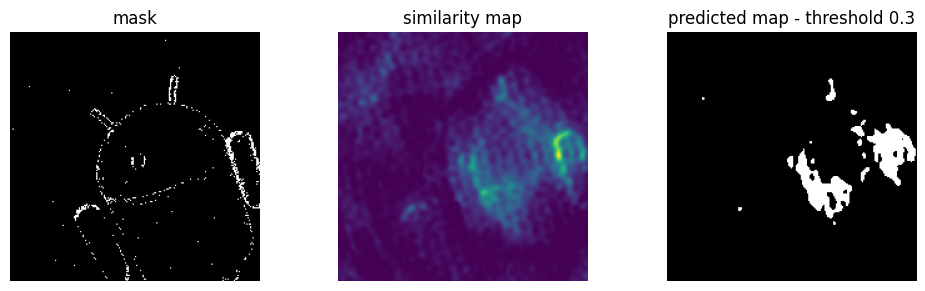

lengthscale   3.5 -- reconstruction IoU 11.02%


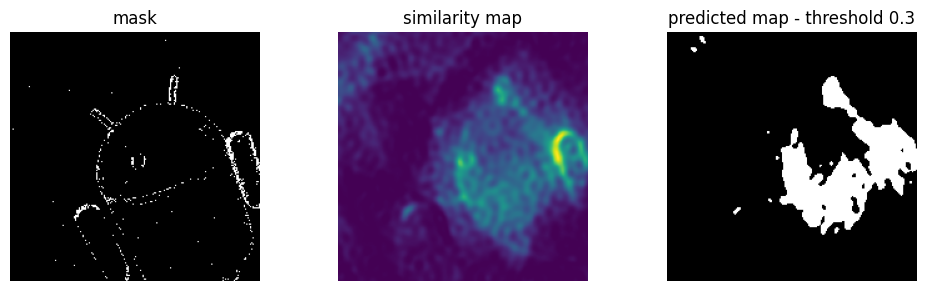

lengthscale   4.0 -- reconstruction IoU 7.27%


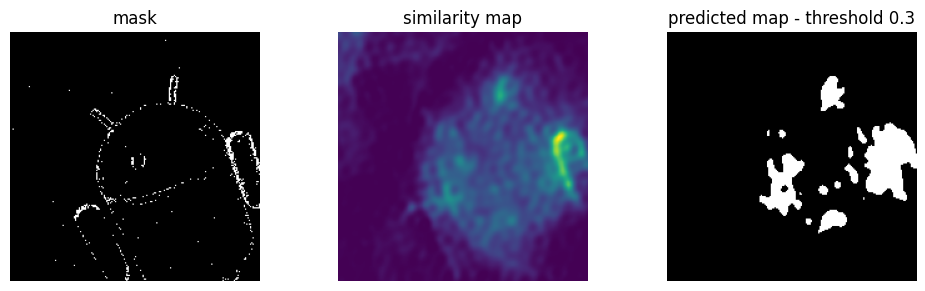

lengthscale   4.5 -- reconstruction IoU 10.32%


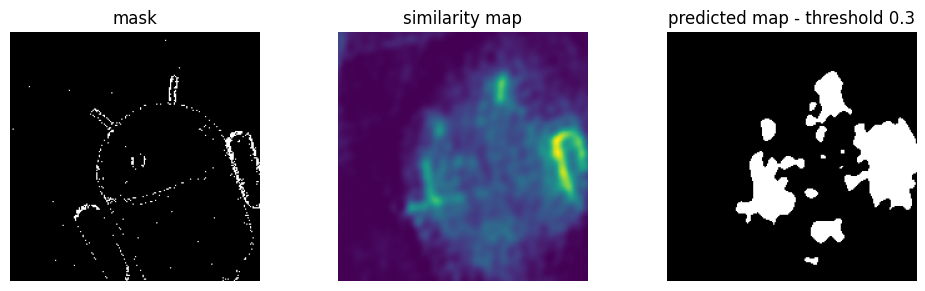

lengthscale   5.0 -- reconstruction IoU 8.67%


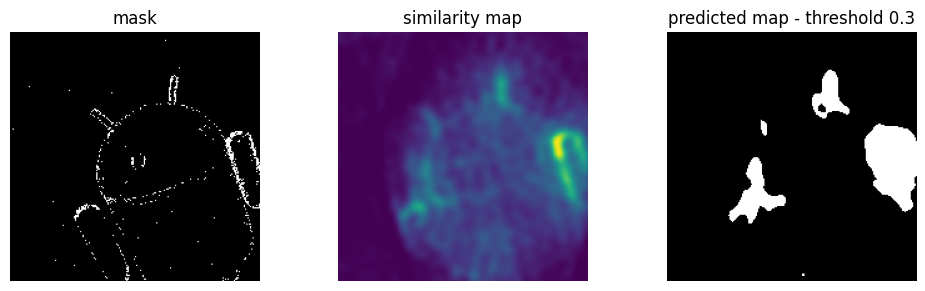

lengthscale   5.5 -- reconstruction IoU 12.20%


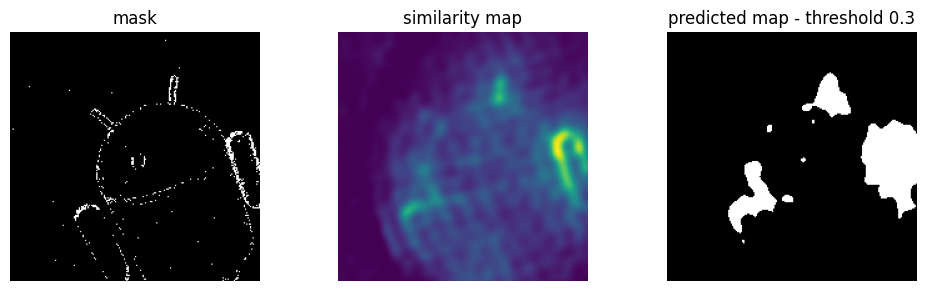

lengthscale   6.0 -- reconstruction IoU 11.28%


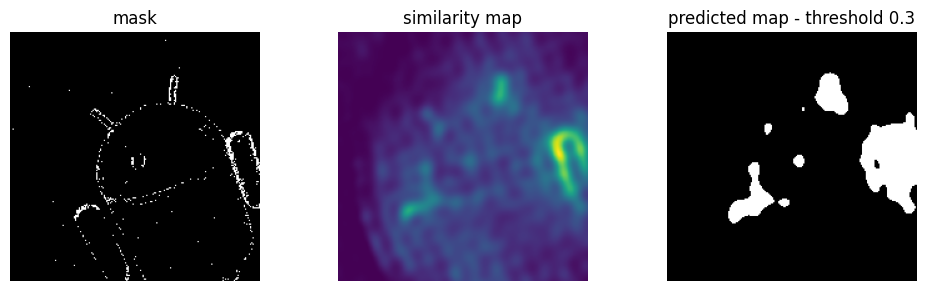

lengthscale   6.5 -- reconstruction IoU 11.84%


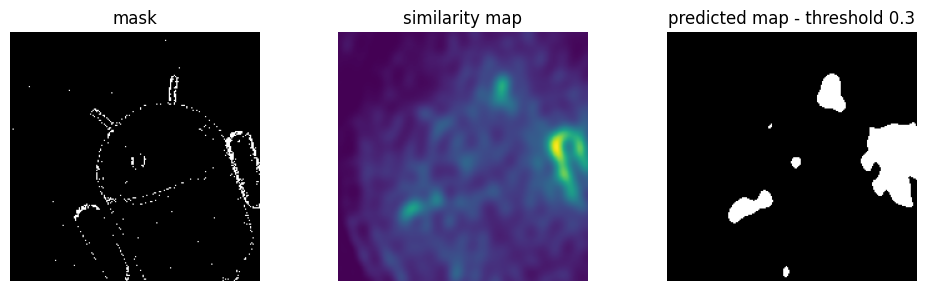

lengthscale   7.0 -- reconstruction IoU 12.71%


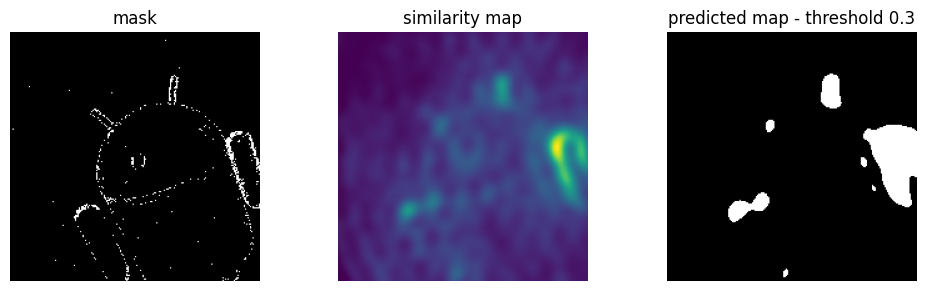

lengthscale   7.5 -- reconstruction IoU 14.78%


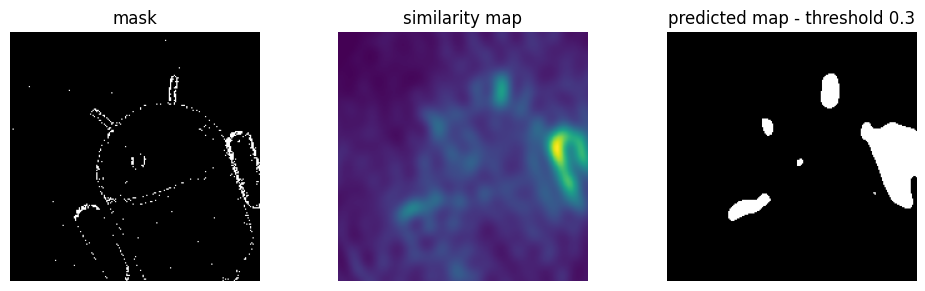

lengthscale   8.0 -- reconstruction IoU 14.65%


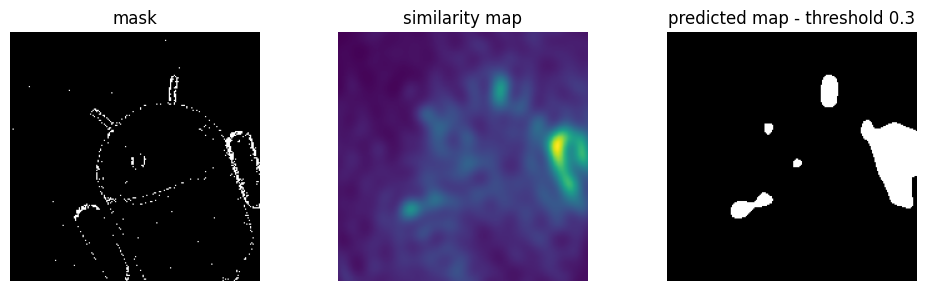

lengthscale   8.5 -- reconstruction IoU 14.36%


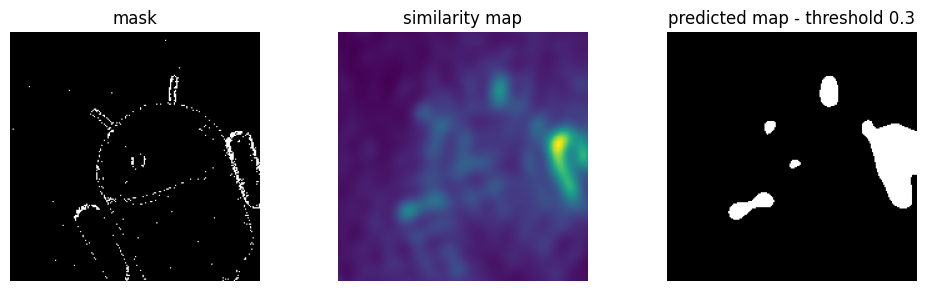

lengthscale   9.0 -- reconstruction IoU 14.41%


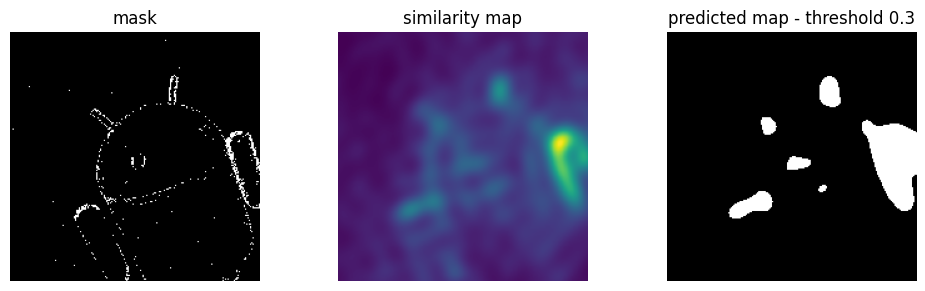

lengthscale   9.5 -- reconstruction IoU 13.91%
CPU times: user 4min 33s, sys: 28.1 s, total: 5min 1s
Wall time: 27.1 s


In [4]:
%%time
THRESHOLD = 0.3

# Fix random seed
SEED = 0
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)

# Define ssp dimension and resolution of grid space - n_scales * n_rotates * 6 + 1
RES_X, RES_Y = 200, 200

for ls in np.arange(0.5, 10, 0.5):
    # Initialize SSP space
    loc_space = sspspace.HexagonalSSPSpace(domain_dim=2, n_rotates=13, n_scales=13)
    loc_space.update_lengthscale([ls, ls])

    # Create nengo spa vocabulary 
    vocab = spa.Vocabulary(dimensions=loc_space.ssp_dim, pointer_gen=np.random.RandomState(0))
    vocab.populate('Object1')

    # Generate xy coordinates -- this takes a while (can be excluded, only used for visualizations)
    x_coords, y_coords = np.meshgrid(np.arange(0, RES_X), np.arange(0, RES_Y), indexing='ij')
    coords = np.stack((x_coords.flatten(), y_coords.flatten()), axis=-1)
    ssp_grid = loc_space.encode(coords)
    ssp_grid = ssp_grid.reshape((RES_X, RES_Y, -1))

    # Encode first image 
    mask = all_imgs[1] == 1

    # Get these xy coordinates from SSPs
    encoded_coords = ssp_grid[:, :, :][mask]
    encoded_label = vocab['Object1'].v

    # Bind the encoded coordinates with the semantic pointer
    bound_vectors = encoded_coords * encoded_label[None, :]
    memory = np.sum(bound_vectors.T, axis=1)[None, :]
    #memory = sspspace.ssp.normalize(memory[None, :])

    # Retrieve the semantic pointer for the object and invert
    prompt = sspspace.SSP(encoded_label[None, :])
    ret_val = memory * ~prompt
    assert type(ret_val) == sspspace.ssp.SSP, 'Casting error'

    sims = np.dot(ret_val, ssp_grid[:, :, :].reshape(-1, loc_space.ssp_dim).T)
    sims = np.array(sims).reshape(RES_X, RES_Y)
    sims = sims ** 2
    sims = sims / np.max(sims)

    plot_sample(mask, sims, threshold=THRESHOLD)
    iou, _ = calc_iou(sims > THRESHOLD, mask)
    print(f'lengthscale {ls:5} -- reconstruction IoU {iou:.2%}')

## Encode multiple images in 2D

In [6]:
file_lst

['android_001_roi.png',
 'android_002_roi.png',
 'android_003_roi.png',
 'android_004_roi.png',
 'android_005_roi.png',
 'android_006_roi.png',
 'android_007_roi.png',
 'android_008_roi.png',
 'android_009_roi.png',
 'android_010_roi.png',
 'android_011_roi.png',
 'android_012_roi.png',
 'android_013_roi.png',
 'android_014_roi.png',
 'android_015_roi.png',
 'android_017_roi.png',
 'android_018_roi.png',
 'android_019_roi.png',
 'android_020_roi.png',
 'android_021_roi.png',
 'android_023_roi.png',
 'android_024_roi.png',
 'android_025_roi.png',
 'android_026_roi.png',
 'android_027_roi.png',
 'android_028_roi.png',
 'android_029_roi.png',
 'android_030_roi.png',
 'android_031_roi.png',
 'android_032_roi.png',
 'android_033_roi.png',
 'android_035_roi.png',
 'android_036_roi.png',
 'android_037_roi.png',
 'android_038_roi.png',
 'android_039_roi.png',
 'android_040_roi.png',
 'android_041_roi.png',
 'android_042_roi.png',
 'android_043_roi.png',
 'android_044_roi.png',
 'android_045_ro

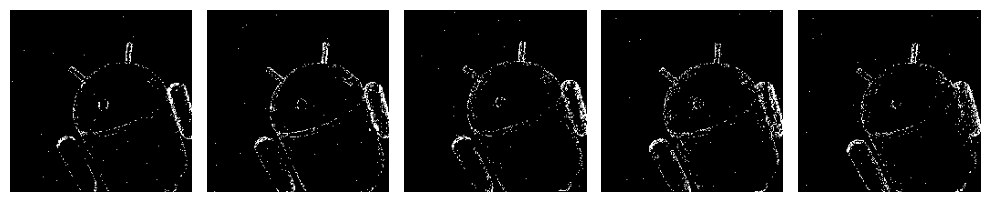

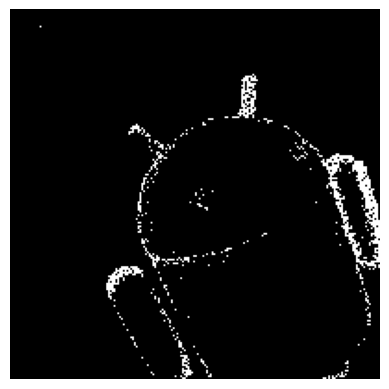

In [11]:
# Select consecutive images -- no skip
fig, axs = plt.subplots(figsize=(10, 4), ncols=5, nrows=1)
all_imgs = {}
for i in range(5):
    
    path = os.path.join(DATA_PATH, file_lst[i])
    z = int(file_lst[i].split('_')[1])
    img = cv2.imread(path)
    
    img = cv2.resize(img, (200, 200), interpolation=cv2.INTER_CUBIC)
    img = np.max(img, axis=2)
    axs[i % 5].imshow(img.astype(float), cmap='gray')
    axs[i % 5].set_axis_off() 
    all_imgs[z] = img

plt.tight_layout()
plt.show()

# Merge images into one image 
test = np.zeros((200, 200))
for k in range(5):
    
    # Encode first image 
    mask = all_imgs[k+1] == 1
    test += mask 
    
plt.imshow(test > 1, cmap='gray')
plt.axis('off')
plt.show()

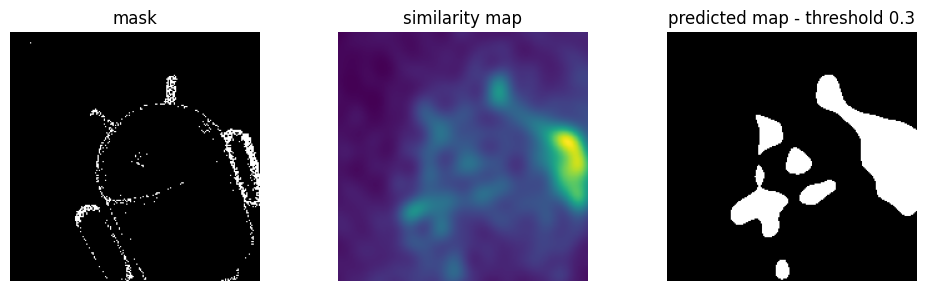

lengthscale    10 -- reconstruction IoU 11.44%
CPU times: user 14.6 s, sys: 1.44 s, total: 16 s
Wall time: 1.54 s


In [12]:
%%time
THRESHOLD = 0.3

# Fix random seed
SEED = 0
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)

# Define ssp dimension and resolution of grid space - n_scales * n_rotates * 6 + 1
RES_X, RES_Y = 200, 200
ls = 10
#for ls in np.arange(5, 20, 1):
# Initialize SSP space
loc_space = sspspace.HexagonalSSPSpace(domain_dim=2, n_rotates=13, n_scales=13)
loc_space.update_lengthscale([ls, ls])

# Create nengo spa vocabulary 
vocab = spa.Vocabulary(dimensions=loc_space.ssp_dim, pointer_gen=np.random.RandomState(0))
vocab.populate('Object1')

# Generate xy coordinates -- this takes a while (can be excluded, only used for visualizations)
x_coords, y_coords = np.meshgrid(np.arange(0, RES_X), np.arange(0, RES_Y), indexing='ij')
coords = np.stack((x_coords.flatten(), y_coords.flatten()), axis=-1)
ssp_grid = loc_space.encode(coords)
ssp_grid = ssp_grid.reshape((RES_X, RES_Y, -1))

# Init memory
memory = sspspace.SSP(np.zeros(loc_space.ssp_dim))
num_points = 0
all_masks = np.zeros((200, 200))
for k in range(1, 6):

    # Encode image 
    mask = all_imgs[k] == 1
    all_masks += mask 
    num_points += len(np.argwhere(mask.flatten()))

    # Get these xy coordinates from SSPs
    encoded_coords = ssp_grid[mask]
    encoded_label = vocab['Object1'].v

    # Bind the encoded coordinates with the semantic pointer
    bound_vectors = encoded_coords * encoded_label[None, :]
    assert type(bound_vectors) == sspspace.ssp.SSP, 'Casting error'
    
    # Accumulate into memory
    memory += bound_vectors.sum(axis=0)

memory = sspspace.ssp.normalize(memory)

# Retrieve the semantic pointer for the object and invert
prompt = sspspace.SSP(encoded_label[None, :])
ret_val = memory * ~prompt
assert type(ret_val) == sspspace.ssp.SSP, 'Casting error'

sims = np.dot(ret_val, ssp_grid[:, :, :].reshape(-1, loc_space.ssp_dim).T)
sims = np.array(sims).reshape(RES_X, RES_Y)
sims = sims ** 2
sims = sims / np.max(sims)

plot_sample(all_masks > 1, sims, threshold=THRESHOLD)
iou, _ = calc_iou(sims > THRESHOLD, mask)
print(f'lengthscale {ls:5} -- reconstruction IoU {iou:.2%}')

## Encode object into memory 3D

In [13]:
%%time
# Fix random seed
SEED = 0
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)

# define ssp dimension and resolution of grid space
# n_scales * n_rotates * 8 + 1
RES_X, RES_Y, RES_Z = 200, 200, 10
LS = 5

# Initialize SSP space
loc_space = sspspace.HexagonalSSPSpace(domain_dim=3, n_rotates=13, n_scales=13)
loc_space.update_lengthscale([LS, LS, LS])

# Create nengo spa vocabulary 
vocab = spa.Vocabulary(dimensions=loc_space.ssp_dim, pointer_gen=np.random.RandomState(0))
vocab.populate('Object1')
vocab.populate('Object2')
    
# Generate xy coordinates -- this takes a while (can be excluded, only used for visualizations)
x_coords, y_coords, z_coords = np.meshgrid(np.arange(0, RES_X), np.arange(0, RES_Y), np.arange(0, RES_Z), indexing='ij')
coords = np.stack((x_coords.flatten(), y_coords.flatten(), z_coords.flatten()), axis=-1)
ssp_grid = loc_space.encode(coords)
ssp_grid = ssp_grid.reshape((RES_X, RES_Y, RES_Z, -1))

print(ssp_grid.shape)

(200, 200, 10, 1353)
CPU times: user 33.3 s, sys: 4.65 s, total: 37.9 s
Wall time: 17 s


In [15]:
GAMMA = 0.99

# compute random discount of attention 
discount = GAMMA ** np.arange(len(all_imgs))
discount = np.round(discount[::-1], decimals=4) # last object remembered best
print(discount)

# init memory
memory = sspspace.SSP(np.zeros(loc_space.ssp_dim))
num_points = 0

for k in all_imgs.keys():

    mask = (all_imgs[k] == 1)
    num_points += len(np.argwhere(mask.flatten()))

    # Get these xy coordinates from SSPs
    z = list(all_imgs.keys()).index(k)

    encoded_coords = ssp_grid[:, :, z, :][mask]
    encoded_label = vocab['Object1'].v

    # Bind the encoded coordinates with the semantic pointer
    bound_vectors = encoded_coords * encoded_label[None, :]
    
    # Add discount of attention
    bound_vectors = np.multiply(discount[z], bound_vectors)
    assert type(bound_vectors) == sspspace.ssp.SSP, 'Casting error'
    
    # Accumulate into scene_ssp
    memory += bound_vectors.sum(axis=0)
    
print('Memory:', memory.shape)
memory = sspspace.ssp.normalize(memory) # normalize memory 

[0.9135 0.9227 0.9321 0.9415 0.951  0.9606 0.9703 0.9801 0.99   1.    ]
Memory: (1, 1353)


## Decode

(1, 1353) (200, 200, 10, 1353)


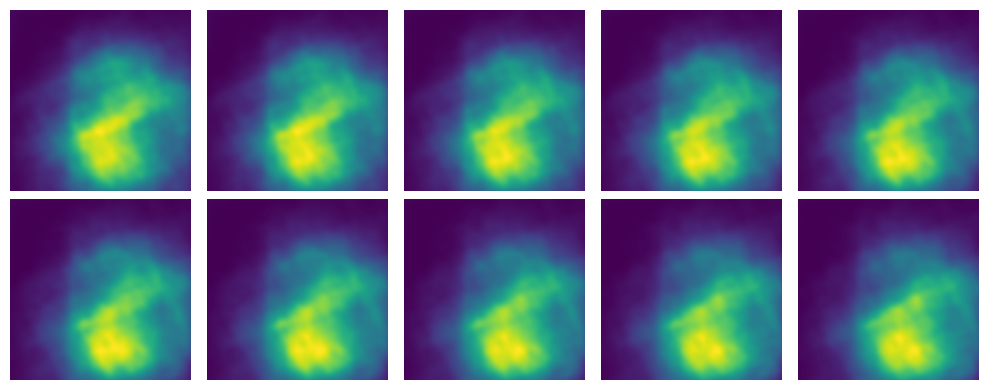

In [16]:
# Retrieve the semantic pointer for the object and invert
prompt = sspspace.SSP(encoded_label)
ret_val = memory * ~prompt

print(ret_val.shape, ssp_grid.shape)
sims = np.dot(ret_val, ssp_grid.reshape(-1, loc_space.ssp_dim).T)
sims = np.array(sims).reshape(RES_X, RES_Y, RES_Z)

fig, axs = plt.subplots(figsize=(10, 4), ncols=5, nrows=2)

for i in range(10):
    sims_map = sims[:, :, i]
    sims_map = sims_map ** 2
    sims_map = sims_map / np.max(sims_map)
    axs[i // 5, i % 5].imshow(sims_map)
    axs[i // 5, i % 5].set_axis_off() 
    
plt.tight_layout()
plt.show()

## Check similarity of single image
- find most likely rotation value z 


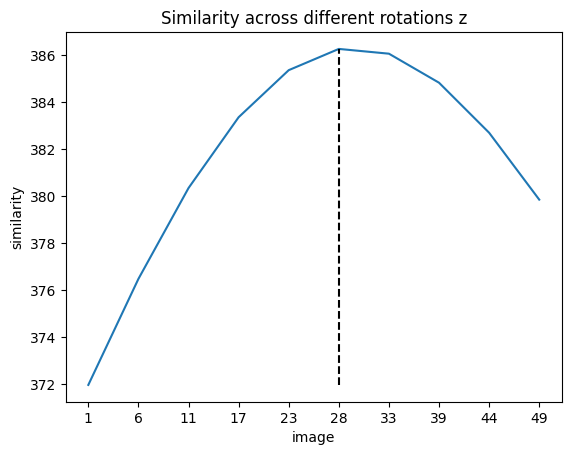

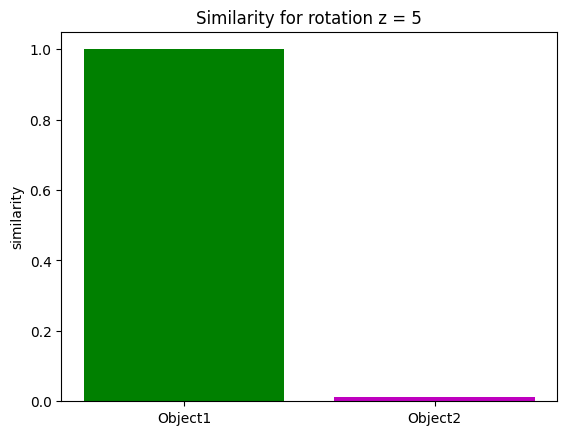

In [19]:
color_lst = ['g', 'm', 'y', 'k', 'b', 'r']

k = 28
z = 0
mask = all_imgs[k] == 1

sim_lst = []
for z in range(RES_Z):
    prompt_coords = ssp_grid[:, :, z, :][mask]
    prompt_coords = prompt_coords.sum(axis=0)[None, :]

    out = memory * ~prompt_coords

    sims = out @ vocab.vectors.T
    idx = np.argmax(sims)
    #print(z, sims, idx)
    sim_lst.append(sims.squeeze()[idx])

plt.plot(np.arange(RES_Z), sim_lst)
plt.xticks(np.arange(RES_Z), all_imgs.keys())
plt.xlabel('image')

plt.vlines(np.argmax(sim_lst), np.min(sim_lst), np.max(sim_lst), color='k', linestyle='dashed')
plt.ylabel('similarity')
plt.title('Similarity across different rotations z')
plt.show()


# plot similarity of most likely object side
z = np.argmax(sim_lst)

prompt_coords = ssp_grid[:, :, z, :][mask]
prompt_coords = prompt_coords.sum(axis=0)[None, :]

out = memory * ~prompt_coords

sims = out @ vocab.vectors.T
#sims = sims ** 2
sims = sims / np.max(sims)
idx = np.argmax(sims)

plt.bar(np.arange(len(vocab)), sims.squeeze(), tick_label=[str(l) for l in vocab.keys()], color=color_lst[:len(vocab)])
plt.ylabel('similarity')
plt.title(f'Similarity for rotation z = {z}')
plt.show()